In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rabieelkharoua/alzheimers-disease-dataset/alzheimers_disease_data.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
alz_data = pd.read_csv("/kaggle/input/datasets/rabieelkharoua/alzheimers-disease-dataset/alzheimers_disease_data.csv")
df =alz_data
alz_data 

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,...,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,...,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,...,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,...,0,0,3.785399,0,0,0,0,1,1,XXXConfid


In [4]:
print(df.head())

   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   BehavioralProblems       ADL  Confusion  Disorientation  \
0     

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [6]:
df  = df.drop('DoctorInCharge', axis=1)
df = df.drop('PatientID', axis=1)

In [7]:
df_w = df.copy()

In [8]:
df.dtypes

Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints               int64
BehavioralProblems             int64
ADL                          float64
C

## Explorative Data Analysis 

In [9]:
# Getting a summary(statistical) of the data 
print("Statistical summary of numeric features:")
df.describe().T

Statistical summary of numeric features:


,count,mean,std,min,25%,50%,75%,max
Age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000
Gender,2149.0,0.506282,0.500077,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2149.0,0.697534,0.996128,0.000000,0.000000,0.000000,1.000000,3.000000
EducationLevel,2149.0,1.286645,0.904527,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
Smoking,2149.0,0.288506,0.453173,0.000000,0.000000,0.000000,1.000000,1.000000
AlcoholConsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346
SleepQuality,2149.0,7.051081,1.763573,4.002629,5.482997,7.115646,8.562521,9.999840


### Checking for duplicates (None found )

In [10]:
print("The number of duplicated rows is:", df.duplicated().sum())

The number of duplicated rows is: 0


 a copy for visualization

In [11]:
df1 = df.copy()

creatinng mappings for categorical features 

In [12]:
mapping = {
    'Gender': {0: 'Male', 1: 'Female'},
    'Ethnicity': {0: 'Caucasian', 1: 'African American', 2: 'Asian', 3: 'Other'},
    'EducationLevel': {0: 'None', 1: 'High School', 2: "Bachelor's", 3: 'Higher'},
    'Smoking': {0: 'Non-smoker', 1: 'Smoker'},
    'FamilyHistoryAlzheimers': {0: 'No', 1: 'Yes'},
    'CardiovascularDisease': {0: 'No', 1: 'Yes'},
    'Diabetes': {0: 'No', 1: 'Yes'},
    'Depression': {0: 'No', 1: 'Yes'},
    'HeadInjury': {0: 'No', 1: 'Yes'},
    'Hypertension': {0: 'No', 1: 'Yes'},
    'MemoryComplaints': {0: 'No', 1: 'Yes'},
    'BehavioralProblems': {0: 'No', 1: 'Yes'},
    'Confusion': {0: 'No', 1: 'Yes'},
    'Disorientation': {0: 'No', 1: 'Yes'},
    'PersonalityChanges': {0: 'No', 1: 'Yes'},
    'DifficultyCompletingTasks': {0: 'No', 1: 'Yes'},
    'Forgetfulness': {0: 'No', 1: 'Yes'},
    'Diagnosis': {0: "No Alzheimer's", 1: "Alzheimer's"}
}

In [13]:
for col, map_dict in mapping.items():
    if col in df1.columns:
        df1[col] = df1[col].map(map_dict)

In [14]:
df1.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,Male,Caucasian,Bachelor's,22.927749,Non-smoker,13.297218,6.327112,1.347214,9.025679,...,6.518877,No,No,1.725883,No,No,No,Yes,No,No Alzheimer's
1,89,Male,Caucasian,None,26.827681,Non-smoker,4.542524,7.619885,0.518767,7.151293,...,7.118696,No,No,2.592424,No,No,No,No,Yes,No Alzheimer's
2,73,Male,Other,High School,17.795882,Non-smoker,19.555085,7.844988,1.826335,9.673574,...,5.895077,No,No,7.119548,No,Yes,No,Yes,No,No Alzheimer's
3,74,Female,Caucasian,High School,33.800817,Smoker,12.209266,8.428001,7.435604,8.392554,...,8.965106,No,Yes,6.481226,No,No,No,No,No,No Alzheimer's
4,89,Male,Caucasian,None,20.716974,Non-smoker,18.454356,6.310461,0.795498,5.597238,...,6.045039,No,No,0.014691,No,No,Yes,Yes,No,No Alzheimer's


# Checking for class imbalance

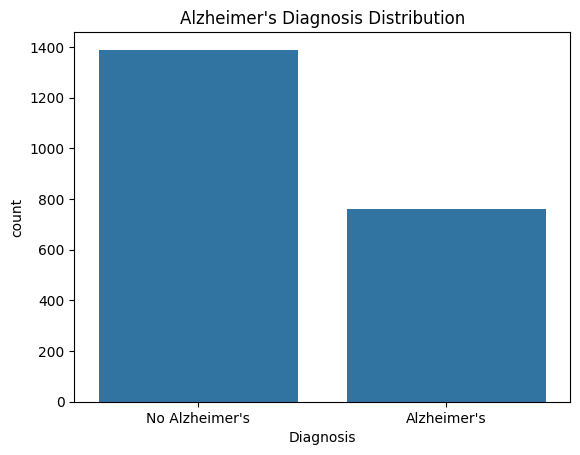

In [15]:
sns.countplot(x="Diagnosis", data=df1)
plt.title("Alzheimer's Diagnosis Distribution")
plt.show()

### there seems to be a little class imbalance but its is not that massive.

## SMOTE 
### We need to apply smote to balance the dataset

In [16]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
from collections import Counter

In [17]:
X = df_w.drop("Diagnosis", axis=1)   # Replace 'Diagnosis' with your target column
y = df_w["Diagnosis"]

In [18]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, stratify=y, random_state=42
# )


X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=42
)

In [19]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [20]:
smote = SMOTE(random_state=42)
X_res, y_resampled = smote.fit_resample(X_train_scaled, y_train)


X_resampled = pd.DataFrame(X_res, columns=X_train_scaled.columns)

In [21]:
print("Before:", Counter(y_train))
print("After:", Counter(y_resampled))


Before: Counter({0: 833, 1: 456})
After: Counter({0: 833, 1: 833})


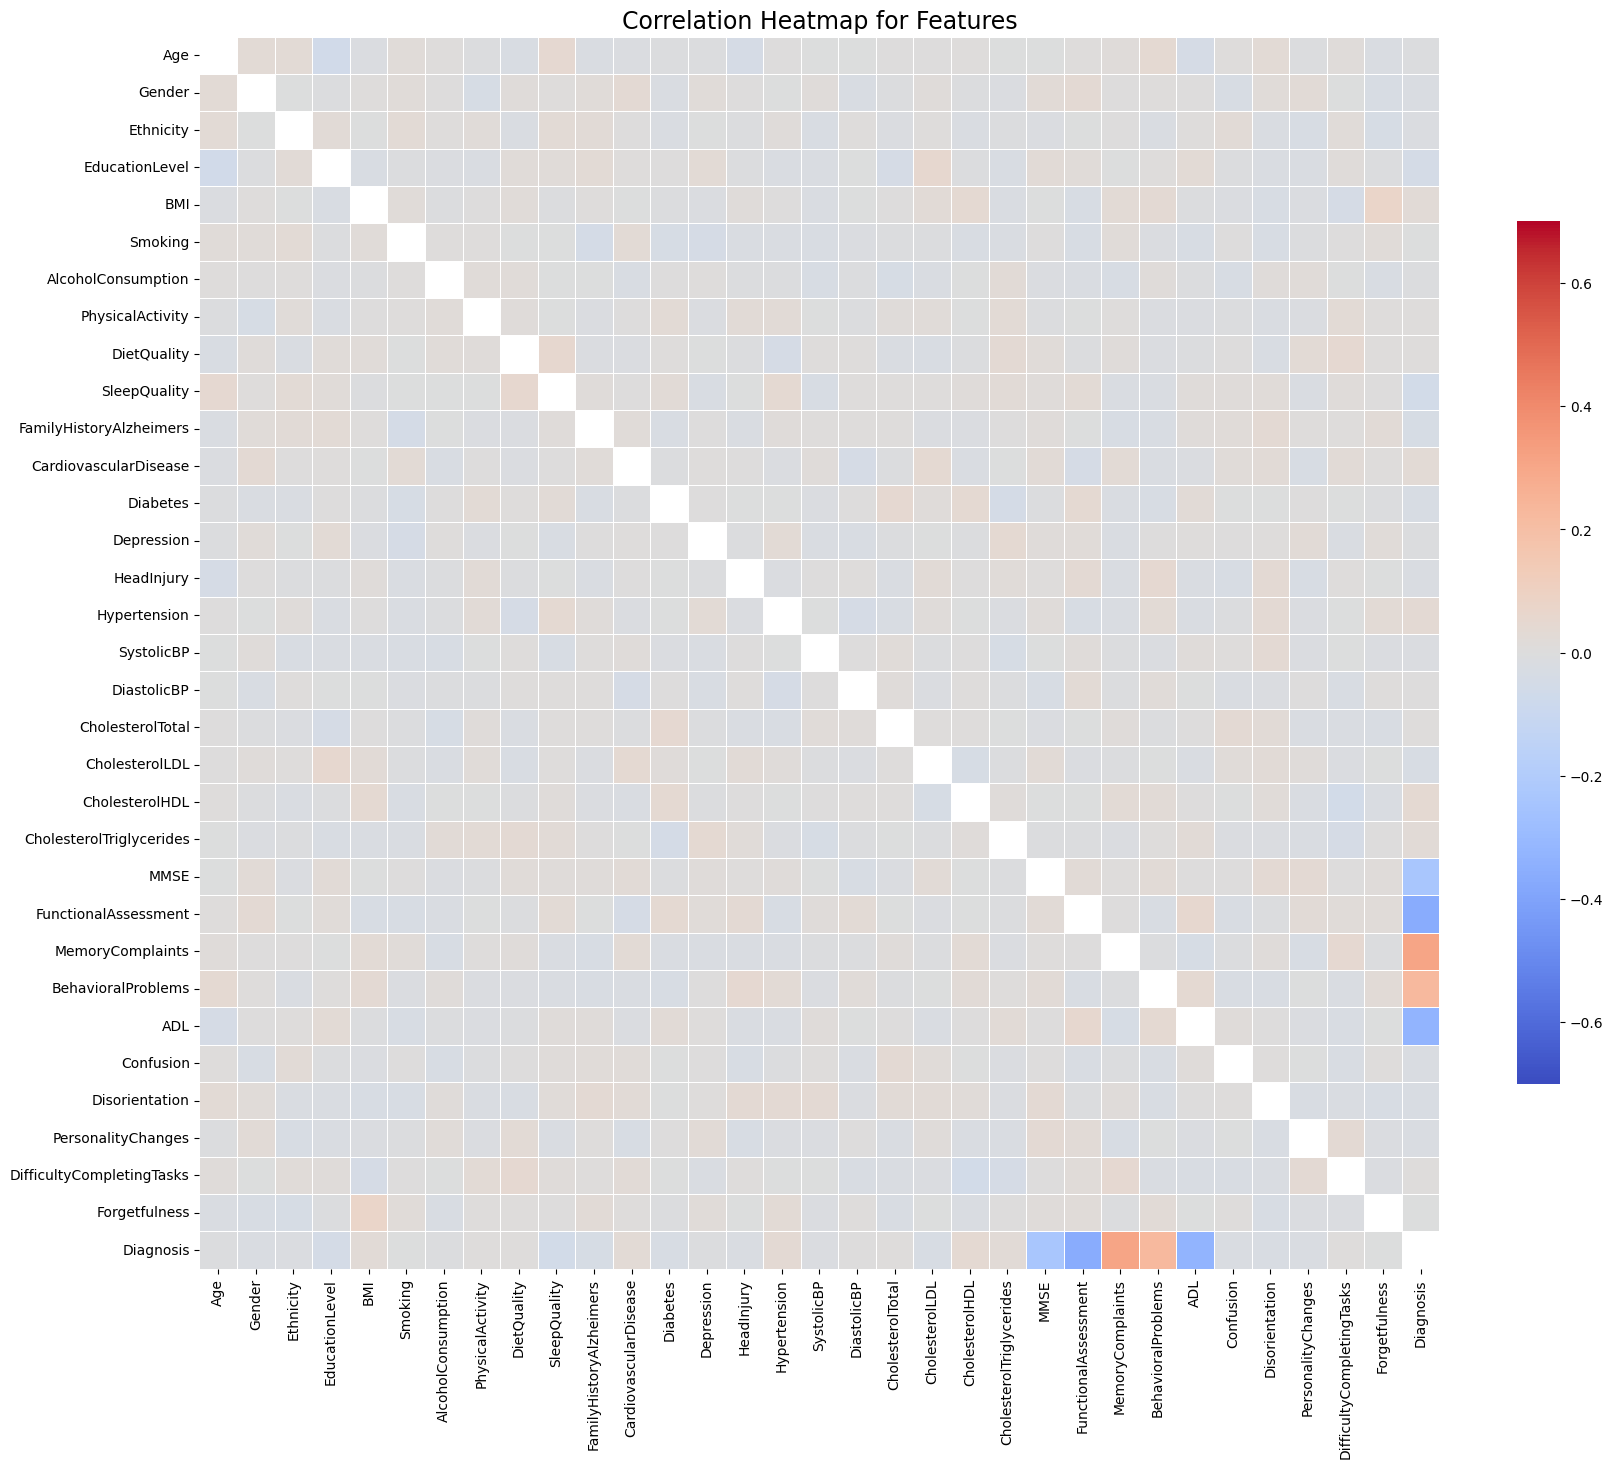

In [22]:
df_cor = df_w.copy()
corr = df_cor.corr()


mask = np.eye(corr.shape[0], dtype=bool)

plt.figure(figsize=(20,16))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-0.7,
    vmax=0.7,
    linewidths=0.7,
    cbar_kws={"shrink": 0.7}
)

plt.title("Correlation Heatmap for Features", fontsize=17)
plt.show()

It could be noted that there is a higher correlation between diagnosis and MemoryComplaints, BehaviourProblems, Functional Assessment, MMSE and ADL. With High values in Memory Complaints and Behaviour Problems indicating Alzheimer possibility and low values in Functional Assessment, MMSE and ADL indicating Alzheimer possibility

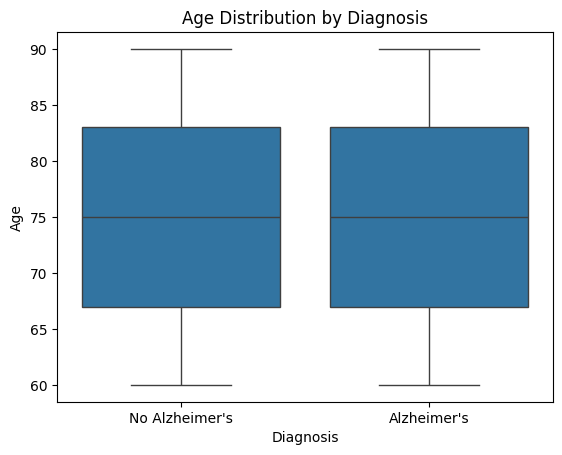

In [23]:
#Age vs Diagnosis
sns.boxplot(x="Diagnosis", y="Age", data=df1)
plt.title("Age Distribution by Diagnosis")
plt.show()

The average age for both people with and without Alzheimer seems to 75

# Modelling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import lightgbm as lgb
import shap

# Separate features and target
#X = df.drop("Diagnosis", axis=1)   # Replace 'Diagnosis' with your target column
#y = df["Diagnosis"]

# Train-test split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_resampled)
# X_test_scaled = scaler.transform(X_test)


In [25]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.001, random_state=42),
    "LightGBM": lgb.LGBMClassifier(n_estimators=200, learning_rate=0.002, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(200,), max_iter=1000, random_state=42)
}



Logistic Regression Val Results:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87       278
           1       0.75      0.80      0.77       152

    accuracy                           0.83       430
   macro avg       0.82      0.83      0.82       430
weighted avg       0.84      0.83      0.84       430


Logistic Regression Test Results:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84       278
           1       0.69      0.82      0.75       152

    accuracy                           0.81       430
   macro avg       0.79      0.81      0.80       430
weighted avg       0.82      0.81      0.81       430



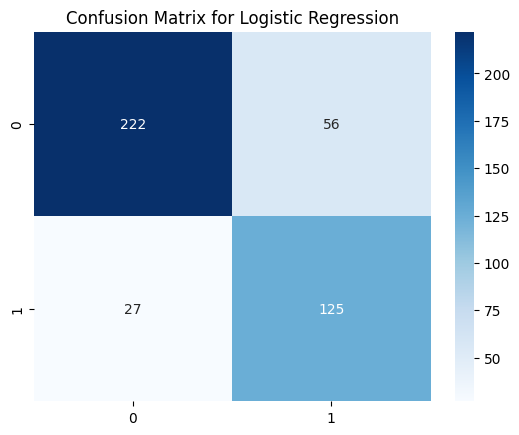


Random Forest Val Results:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       278
           1       0.94      0.89      0.92       152

    accuracy                           0.94       430
   macro avg       0.94      0.93      0.94       430
weighted avg       0.94      0.94      0.94       430


Random Forest Test Results:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       278
           1       0.93      0.89      0.91       152

    accuracy                           0.94       430
   macro avg       0.94      0.93      0.93       430
weighted avg       0.94      0.94      0.94       430



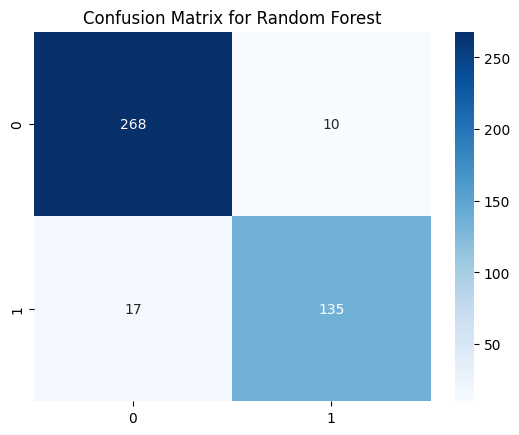


XGBoost Val Results:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       278
           1       0.94      0.91      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430


XGBoost Test Results:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       278
           1       0.93      0.91      0.92       152

    accuracy                           0.94       430
   macro avg       0.94      0.94      0.94       430
weighted avg       0.94      0.94      0.94       430



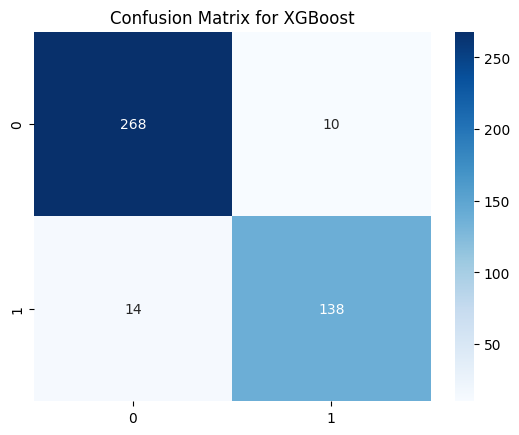

[LightGBM] [Info] Number of positive: 833, number of negative: 833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001502 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4266
[LightGBM] [Info] Number of data points in the train set: 1666, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

LightGBM Val Results:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95       278
           1       0.92      0.90      0.91       152

    accuracy                           0.94       430
   macro avg       0.93      0.93      0.93       430
weighted avg       0.94      0.94      0.94       430


LightGBM Test Results:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94       278
           1     

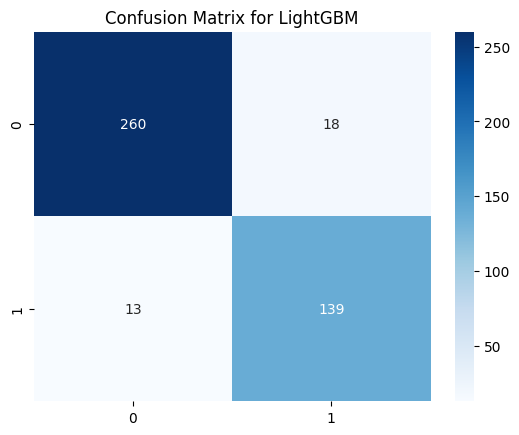


AdaBoost Val Results:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93       278
           1       0.87      0.88      0.88       152

    accuracy                           0.91       430
   macro avg       0.90      0.90      0.90       430
weighted avg       0.91      0.91      0.91       430


AdaBoost Test Results:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92       278
           1       0.83      0.89      0.86       152

    accuracy                           0.90       430
   macro avg       0.88      0.89      0.89       430
weighted avg       0.90      0.90      0.90       430



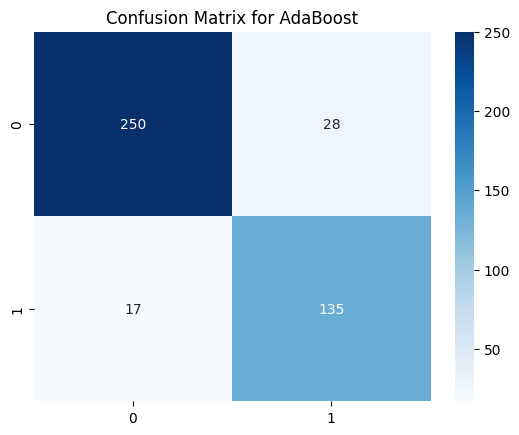


MLP Val Results:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       278
           1       0.74      0.67      0.71       152

    accuracy                           0.80       430
   macro avg       0.79      0.77      0.78       430
weighted avg       0.80      0.80      0.80       430


MLP Test Results:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85       278
           1       0.74      0.70      0.72       152

    accuracy                           0.81       430
   macro avg       0.79      0.78      0.79       430
weighted avg       0.80      0.81      0.81       430



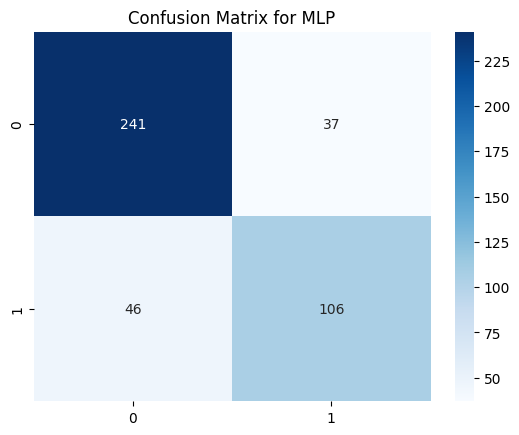

In [26]:
from sklearn.metrics import  confusion_matrix


results = {}

for name, model in models.items():
    if name == "Logistic Regression" or "MLP":
        model.fit(X_resampled, y_resampled)
        y_val_pred = model.predict(X_val_scaled)
        y_test_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_resampled, y_resampled)
        y_val_pred = model.predict(X_val_scaled)
        y_test_pred = model.predict(X_test_scaled)
    
    val_acc = accuracy_score(y_test, y_val_pred)
    val_f1 = f1_score(y_test, y_val_pred, average="weighted")
    val_recall = recall_score(y_test, y_val_pred)
    val_precision = precision_score (y_val, y_val_pred)
    
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")
    test_recall = recall_score(y_test, y_test_pred)
    test_precision = precision_score (y_test, y_test_pred)
    
    results[name] = {
        "Val Accuracy": val_acc,
        "Val F1-score": val_f1,
        "Val Recall":val_recall,
        "Val Precision":val_precision,
        "Test Accuracy": test_acc,
        "Test F1-score": test_f1,
        "Test Recall": test_recall,
         "Test Preicion": test_precision
    }
    print(f"\n{name} Val Results:\n", classification_report(y_val, y_val_pred))
    print(f"\n{name} Test Results:\n", classification_report(y_test, y_test_pred))
    sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.show()


In [27]:
results_df = pd.DataFrame(results).T
print(results_df)


                     Val Accuracy  Val F1-score  Val Recall  Val Precision  \
Logistic Regression      0.555814      0.558546    0.401316       0.751553   
Random Forest            0.597674      0.595434    0.407895       0.937931   
XGBoost                  0.595349      0.594096    0.414474       0.939189   
LightGBM                 0.597674      0.596749    0.421053       0.919463   
AdaBoost                 0.572093      0.572719    0.401316       0.870130   
MLP                      0.583721      0.578386    0.361842       0.744526   

                     Test Accuracy  Test F1-score  Test Recall  Test Preicion  
Logistic Regression       0.806977       0.810071     0.822368       0.690608  
Random Forest             0.937209       0.936860     0.888158       0.931034  
XGBoost                   0.944186       0.944013     0.907895       0.932432  
LightGBM                  0.927907       0.928163     0.914474       0.885350  
AdaBoost                  0.895349       0.896120    

[LightGBM] [Info] Number of positive: 833, number of negative: 833
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000855 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4266
[LightGBM] [Info] Number of data points in the train set: 1666, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


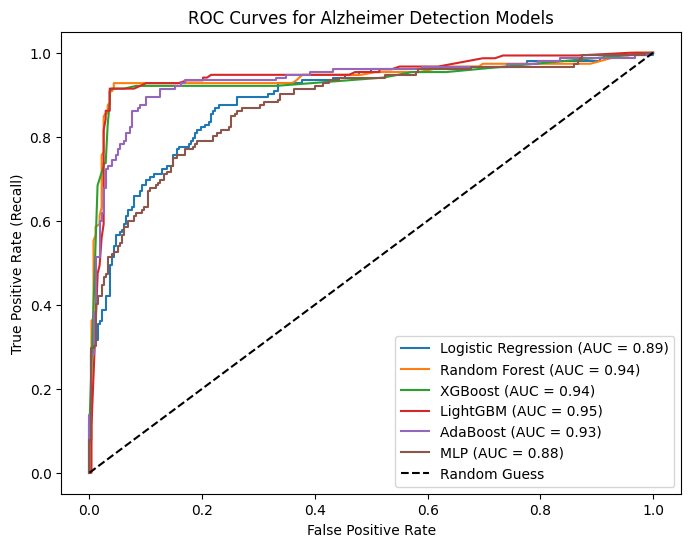

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Fit models and plot ROC curves
plt.figure(figsize=(8, 6))

for name, model in models.items():
    # Train
    model.fit(X_resampled, y_resampled)
    
    # Get probabilities (some models use decision_function instead)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_test_scaled)
    
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    
    # Plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Plot baseline
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves for Alzheimer Detection Models")
plt.legend(loc="lower right")
plt.show()


In [40]:
# ensemble_stacking = StackingClassifier(
#     estimators=[(name, model) for name, model in models.items()],
#     final_estimator = MLPClassifier(max_iter=2000),
#     passthrough=True
# )

In [29]:
from sklearn.ensemble import StackingClassifier
from sklearn.neural_network import MLPClassifier

# Remove MLP from the base estimators
base_estimators = [(name, model) for name, model in models.items() if name != "MLP"]

# Define stacking ensemble with MLP only as final estimator
ensemble_stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=MLPClassifier(max_iter=2000, random_state=42),
    passthrough=True
)


In [30]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

ensemble_voting = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting="soft"   # soft = average probabilities, better for medical data
)

 


In [31]:
ensemble_voting.fit(X_resampled, y_resampled)
ensemble_stacking.fit(X_resampled, y_resampled)

[LightGBM] [Info] Number of positive: 833, number of negative: 833
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000674 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4266
[LightGBM] [Info] Number of data points in the train set: 1666, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 833, number of negative: 833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000441 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4266
[LightGBM] [Info] Number of data points in the train set: 1666, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 666, number of negative: 666
[

StackingClassifier(estimators=[('Logistic Regression',
                                LogisticRegression(max_iter=1000)),
                               ('Random Forest',
                                RandomForestClassifier(n_estimators=200,
                                                       random_state=42)),
                               ('XGBoost',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_catego...
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('LightGBM',
                                LGBMClassifier(learning_rate=0.002,
                                               n_estimators=200,
                                               random_state=42)),
                               ('AdaBoost',
                                AdaBoostClassifier(n_estimators=200,
                                                   random_state=42))],
                   final_estimator=MLPClassifier(max_iter=2000,
                                                 random_state=42),
                   passthrough=True)

In [32]:
print("Voting Ensemble Val Accuracy:", ensemble_voting.score(X_val_scaled, y_val))
print("Stacking Ensemble Val Accuracy:", ensemble_stacking.score(X_val_scaled, y_val))

print("Voting Ensemble Test Accuracy:", ensemble_voting.score(X_test_scaled, y_test))
print("Stacking Ensemble Test Accuracy:", ensemble_stacking.score(X_test_scaled, y_test))

Voting Ensemble Val Accuracy: 0.8790697674418605
Stacking Ensemble Val Accuracy: 0.9069767441860465
Voting Ensemble Test Accuracy: 0.8930232558139535
Stacking Ensemble Test Accuracy: 0.9023255813953488


## Using SHAP for Explainability

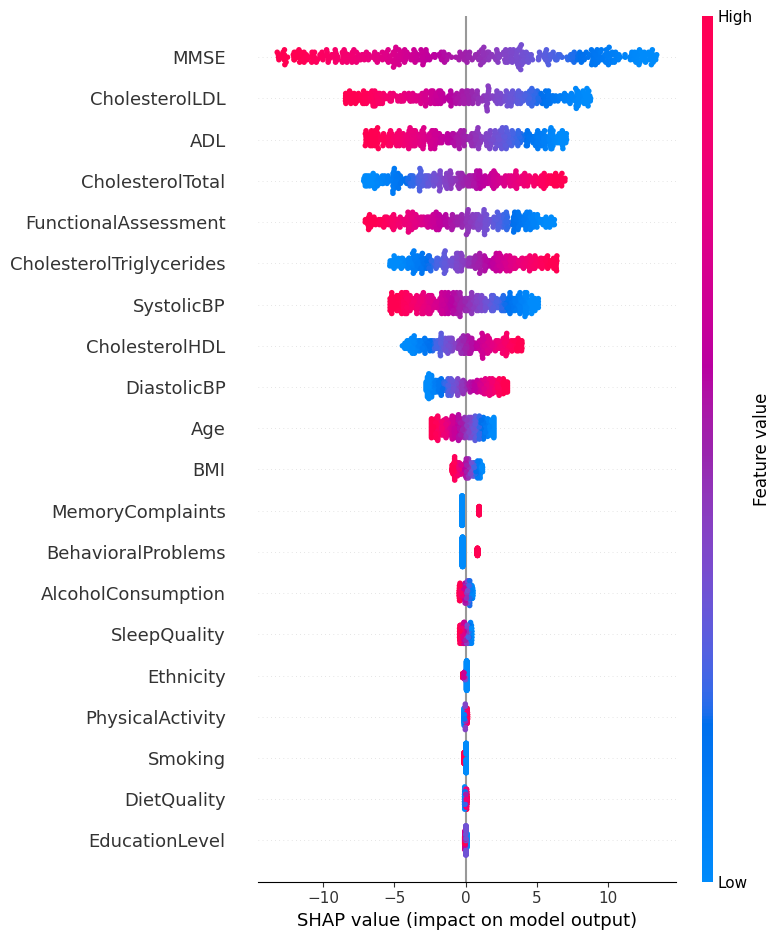

In [33]:
import shap
shap.initjs()
# Example: explain XGBoost
explainer = shap.LinearExplainer(models["Logistic Regression"], X_test)
shap_values = explainer.shap_values(X_test)

# Global importance
shap.summary_plot(shap_values, X_test)

# Local explanation for one patient
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])


  0%|          | 0/430 [00:00<?, ?it/s]

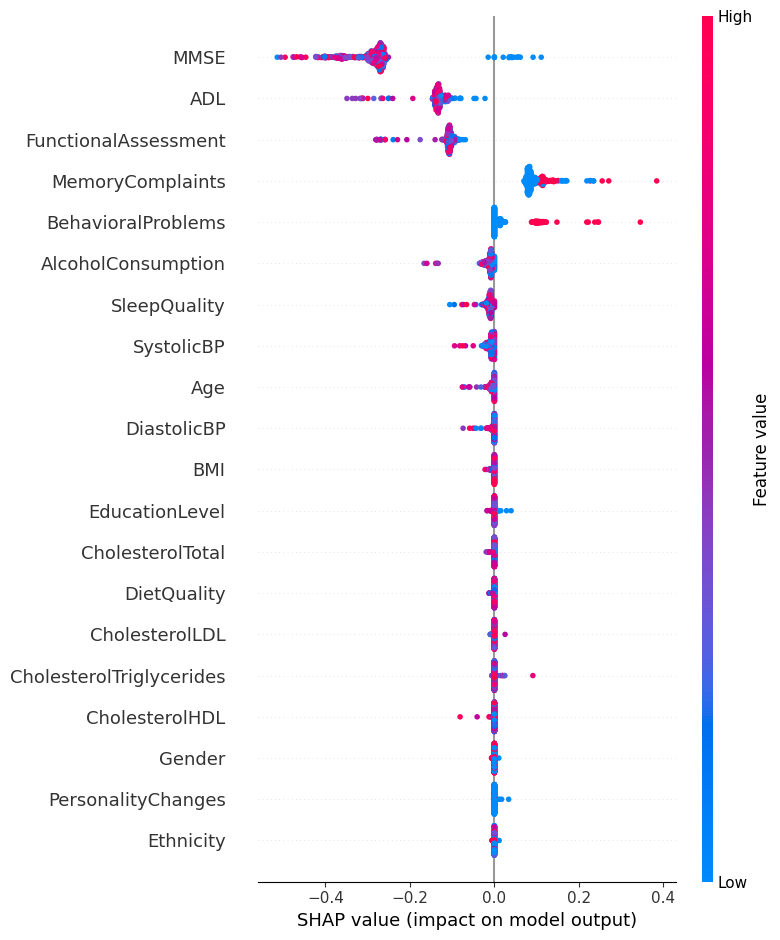

In [74]:
import shap
shap.initjs()

background = X_resampled.sample(100, random_state=0)

explainer = shap.KernelExplainer(models["Random Forest"].predict, background)
shap_values = explainer.shap_values(X_test)

# Global importance
shap.summary_plot(shap_values, X_test)

# Local explanation for one patient
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])

for name in ["XGBoost", "LightGBM"]:
    explainer = shap.TreeExplainer(models[name])
    shap_values = explainer.shap_values(X_test)
    print(name)
    shap.summary_plot(shap_values, X_test, show=True)

shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])


## Using LIME for Explainability <br>
for local Explainabilty

In [40]:
# 1. Grab your feature names
feature_names = X_resampled.columns.tolist()

# 2. Create a "Wrapper" function for LIME
# This converts the internal LIME numpy arrays back into DataFrames
def predict_with_names(data_array):
    # Convert array back to DataFrame so the model recognizes the features
    data_df = pd.DataFrame(data_array, columns=feature_names)
    return model.predict_proba(data_df)

# 3. Use this wrapper in your explanation
exp = lime_explainer1.explain_instance(
    data_row=patient_data.values, 
    predict_fn=predict_with_names,  # Use the wrapper here
    num_features=10
)

In [71]:
# 1. Pick a patient from the scaled test set
i = 10  # Index of the patient you want to explain
patient_data = X_test_scaled.iloc[i]

# 2. Define a prediction function
# Some models need .predict_proba; LIME expects a function that returns probabilities
predict_fn = models["LightGBM"].predict_proba

# 3. Generate explanation
exp = lime_explainer1.explain_instance(
    data_row=patient_data.values, 
    predict_fn=predict_fn,
    num_features=10
)

# 4. Show the result
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [70]:
# 1. Pick a patient from the scaled test set
i = 10  # Index of the patient you want to explain
patient_data = X_test_scaled.iloc[i]

# 2. Define a prediction function
# Some models need .predict_proba; LIME expects a function that returns probabilities
predict_fn = models["Logistic Regression"].predict_proba

# 3. Generate explanation
exp = lime_explainer1.explain_instance(
    data_row=patient_data.values, 
    predict_fn=predict_fn,
    num_features=10
)

# 4. Show the result
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [35]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# For tree-based models (XGBoost, LightGBM, Random Forest)
lime_explainer1 = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=["No Alzheimer", "Alzheimer"],  # adjust to your labels
    mode="classification"
)


In [66]:
# Pick one test instance
i = 90
instance = X_test.iloc[i].values

# Explain prediction
exp = lime_explainer1.explain_instance(
    data_row=instance,
    predict_fn=models["LightGBM"].predict_proba
)

# Show explanation
exp.show_in_notebook(show_table=True)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [68]:
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=df.drop("Diagnosis", axis=1).columns,
    class_names=["No Alzheimer", "Alzheimer"],  # adjust to your labels
    mode="classification"
)

# Pick one test instance
i = 100
instance = X_test.iloc[i].values

# Explain prediction
exp = lime_explainer.explain_instance(
    data_row=instance,
    predict_fn=models["Logistic Regression"].predict_proba
)

# Show explanation
exp.show_in_notebook(show_table=True, show_all=False)




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
